# **Telco Customer Churn — Initial Exploratory Data Analysis**
               
**Tasks Covered:**
  1. Dataset shape
  2. Column names and data types
  3. Column classification (numerical / categorical / binary / target)
  4. Missing value detection
  5. Duplicate detection
  6. Inconsistent values and formatting issues
  7. Key observations summary

# **Load Dataset**

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")



# **Data Overview**

In [81]:

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (7043, 21)

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 0

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
Pape

# **Column Names & Data Types**

In [82]:
# Column names
print(df.columns)

# Data types
print(df.dtypes)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


# **Column Classification**

In [83]:
# Numerical
numerical_cols = ['tenure', 'MonthlyCharges']

# Binary (Yes/No or 0/1)
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
]

# Categorical (more than 2 categories)
categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod'
]

# Special case
special_cols = ['SeniorCitizen']  # 0/1 but numeric

# Target
target = 'Churn'

print("Numerical:", numerical_cols)
print("Binary:", binary_cols)
print("Categorical:", categorical_cols)
print("Target:", target)

Numerical: ['tenure', 'MonthlyCharges']
Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Categorical: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Target: Churn


# **Missing Values Detection**

In [84]:
# Replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", pd.NA)



# **Inconsistent Values / Formatting Issues**

In [85]:
# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [86]:
df['TotalCharges'].dtype

dtype('float64')

# **Handle Missing Values**

In [87]:
# Check missing again
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [88]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [89]:

df.drop(columns=['customerID'], inplace=True)
print('customerID column dropped.')

customerID column dropped.


# **Check unique values**

In [90]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


**Binary inconsistency check**

In [91]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


**Target Imbalance**

In [92]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


# **Summary Statistics for Numerical Features**

In [93]:
# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Summary statistics
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


# **Summary for Contract Types**

In [94]:
# Count
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [95]:
# Percentage
df['Contract'].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


# **Grouped Statistics (VERY IMPORTANT)**

**Charges by Contract Type**

In [96]:
df.groupby('Contract')[['MonthlyCharges', 'TotalCharges']].mean()

,MonthlyCharges,TotalCharges
Contract,,
Month-to-month,66.398490,1369.254581
One year,65.048608,3032.622878
Two year,60.770413,3706.934336


**Tenure by Contract Type**

In [97]:
df.groupby('Contract')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Contract,,,,,,,,
Month-to-month,3875.0,18.036645,17.689054,1.0,3.0,12.0,29.0,72.0
One year,1473.0,42.044807,19.035883,0.0,27.0,44.0,58.0,72.0
Two year,1695.0,56.735103,18.209363,0.0,48.0,64.0,71.0,72.0


# **Final Clean Dataset Summary**

In [98]:
print("\n===== AFTER CLEANING =====")

print("\nShape:", df.shape)

print("\nMissing Values:\n", df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData Types:\n", df.dtypes)


===== AFTER CLEANING =====

Shape: (7043, 20)

Missing Values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 22

Data Types:
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
Paym

# **Churn Distribution (Target Analysis)**

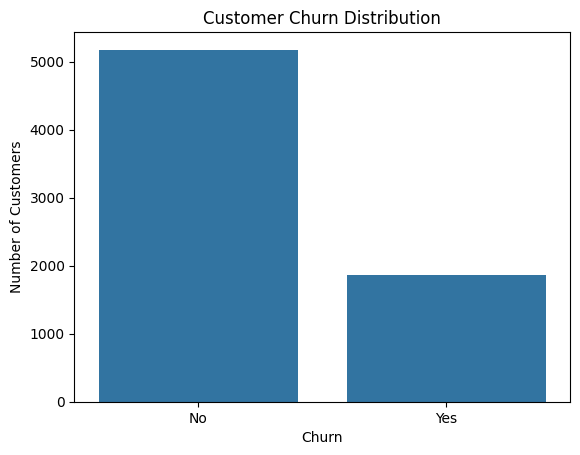

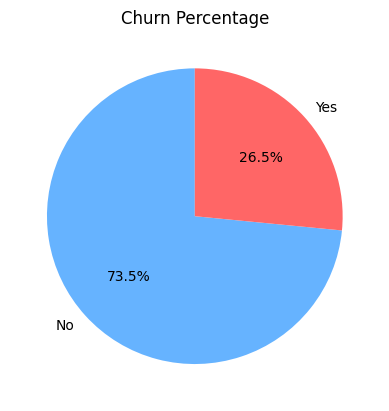

In [99]:
# Countplot
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Pie chart
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#ff6666']
)
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

# **Univariate Analysis (Numerical)**

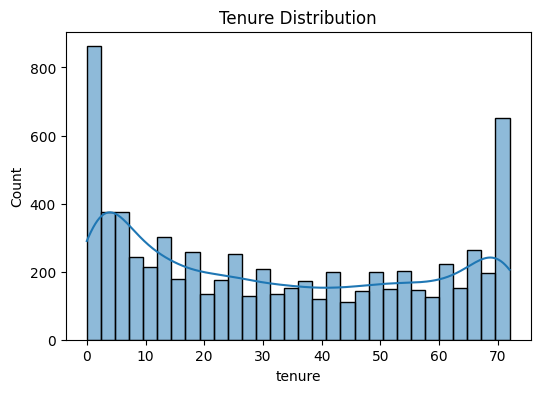

In [100]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

**MonthlyCharges**

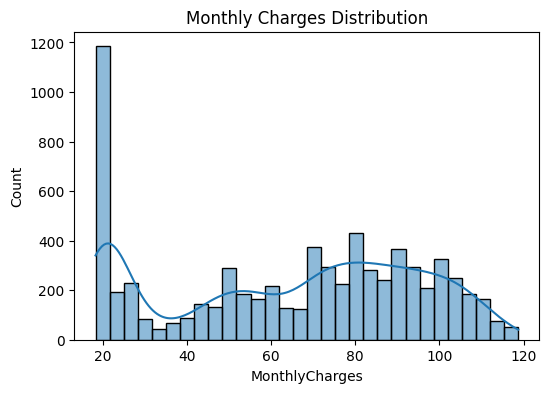

In [101]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

**TotalCharges**

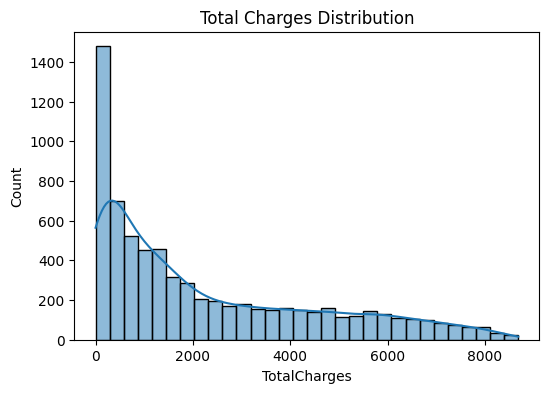

In [102]:
plt.figure(figsize=(6,4))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title("Total Charges Distribution")
plt.show()

# **Univariate Analysis (Categorical)**

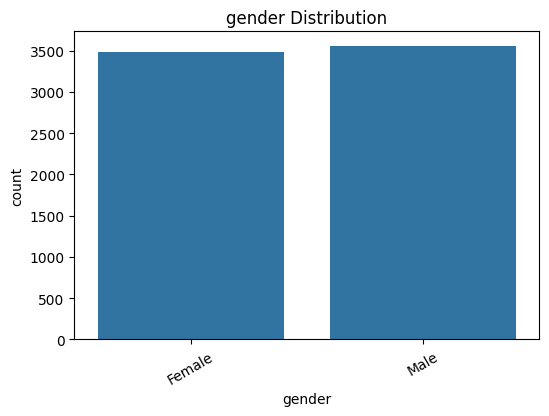

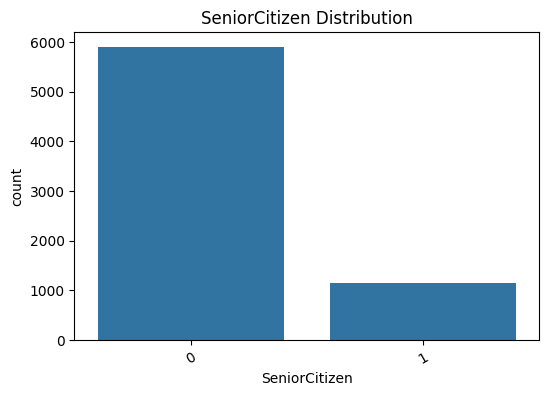

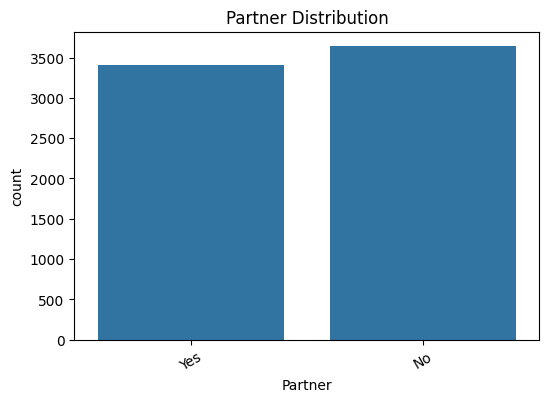

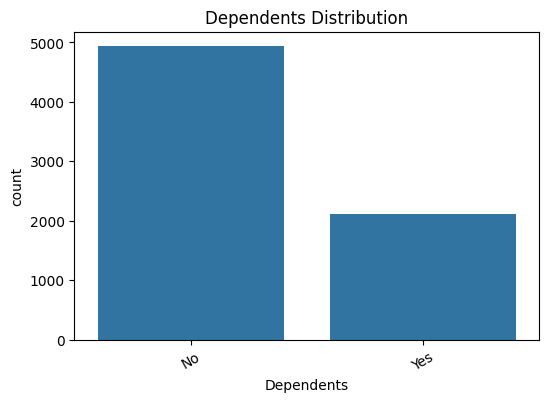

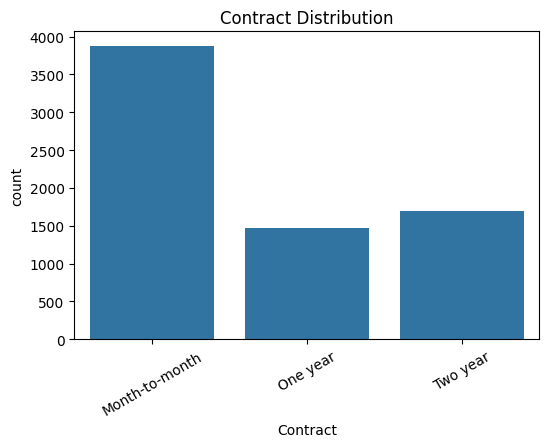

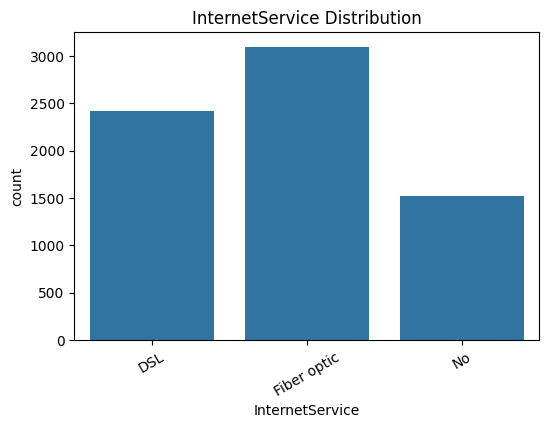

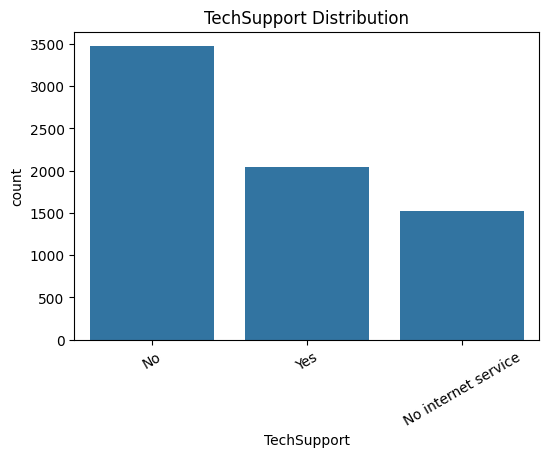

In [103]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents',
            'Contract','InternetService','TechSupport']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=30)
    plt.show()

# **Bivariate Analysis (Against Churn)**

**Gender vs Churn**

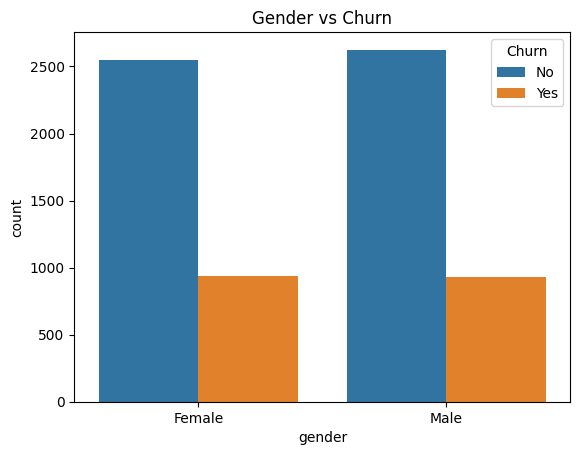

In [104]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

**SeniorCitizen vs Churn**

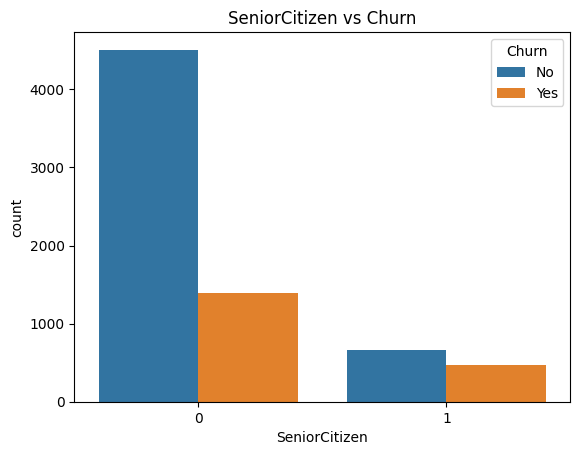

In [105]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("SeniorCitizen vs Churn")
plt.show()

**Partner vs Churn**

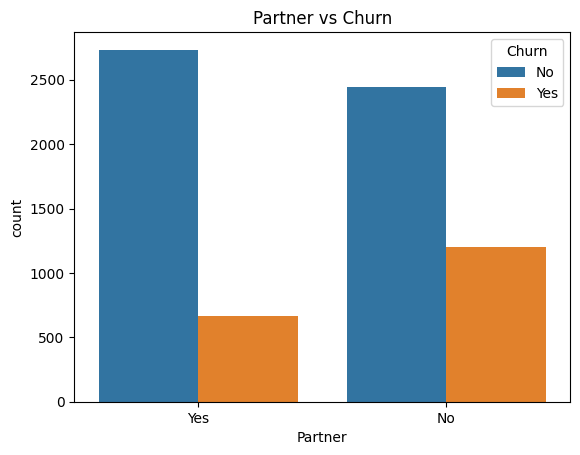

In [106]:
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Partner vs Churn")
plt.show()

**Dependents vs Churn**

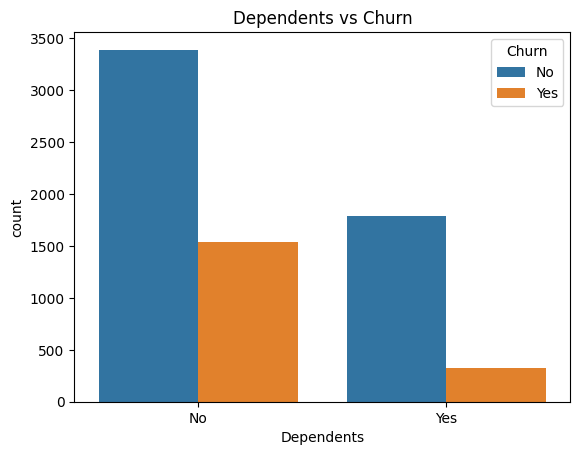

In [107]:
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Dependents vs Churn")
plt.show()

**Contract vs Churn (VERY IMPORTANT)**

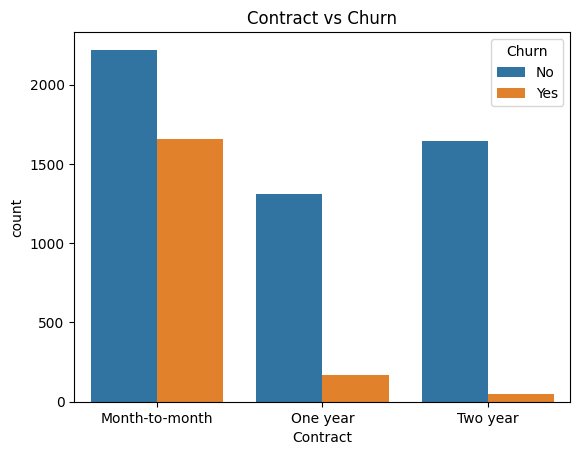

In [108]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract vs Churn")
plt.show()

**InternetService vs Churn**

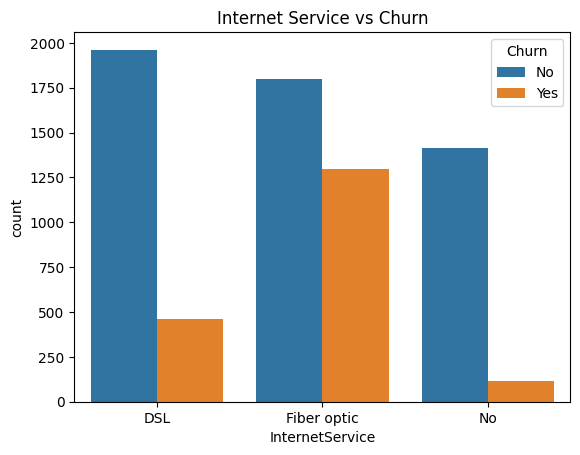

In [109]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

**TechSupport vs Churn**

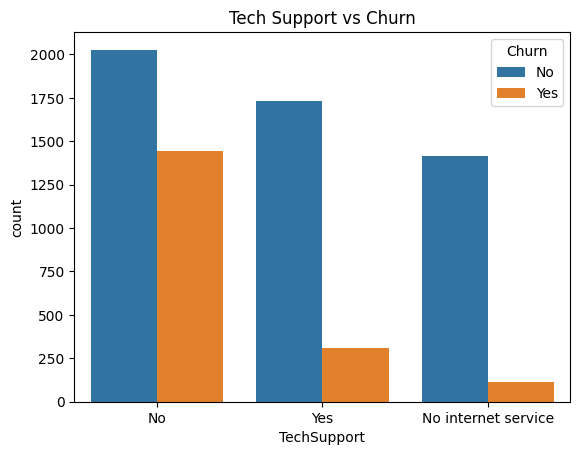

In [110]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Churn")
plt.show()

**OnlineSecurity vs Churn**

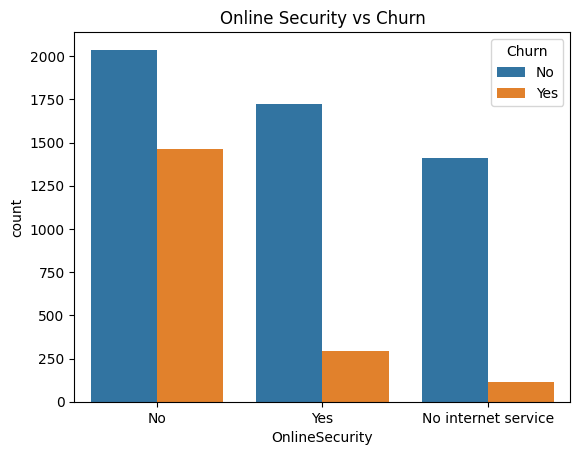

In [111]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Online Security vs Churn")
plt.show()

**MonthlyCharges vs Churn**

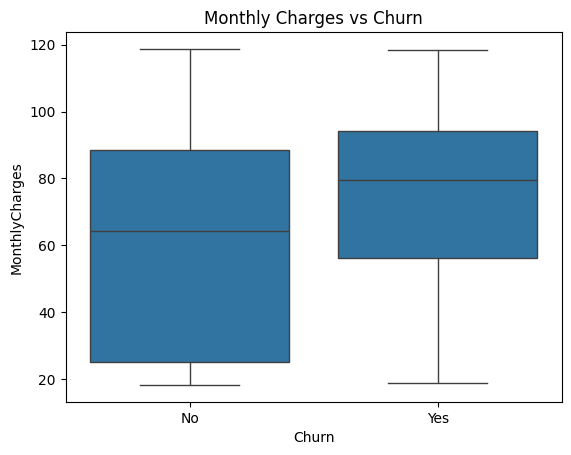

In [112]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Tenure vs Churn**

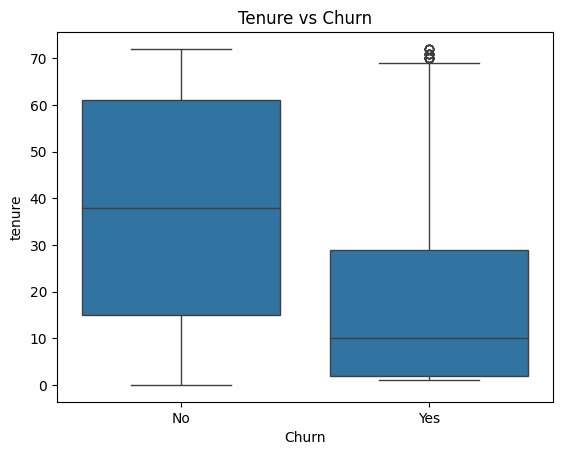

In [113]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# **Multivariate Analysis**

**Correlation (Numerical)**

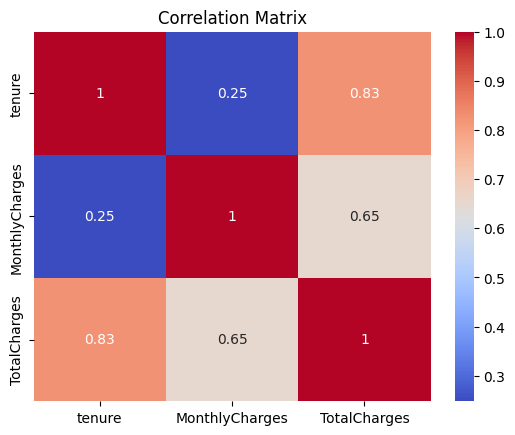

In [114]:
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Contract + Charges + Churn**

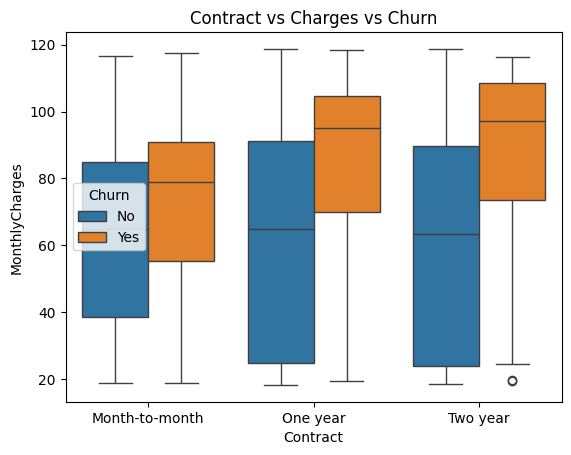

In [115]:
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Contract vs Charges vs Churn")
plt.show()

# **Key Churn Drivers**
**Strong Drivers**           
Contract type (MOST IMPORTANT)      
Tenure           
MonthlyCharges      
TechSupport      
OnlineSecurity

**Medium Drivers**    
InternetService     
SeniorCitizen     

**Weak Drivers**     
Gender

# **Top Findings**
**1.Short-term customers churn the most:** Early engagement is critical

**2.Month-to-month contracts are risky:**
Encourage long-term plan    

**3.High charges increase churn:**
Pricing strategy matters

**4.Lack of support/services increases churn:**
Tech support & security are key

**5.Family-oriented customers stay longer:**
Dependents & partners reduce churn

                                        
                                               

# **Encode Features (Label Encoding)**

In [116]:

df['Churn'] = (
    df['Churn']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Churn value counts:')
print(df['Churn'].value_counts())
print()
print('Churn rate: {:.1f}%'.format(df['Churn'].mean() * 100))


Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


**Encode Categorical Features**

In [117]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Refresh the categorical columns list (after dropping customerID and target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Categorical columns encoded:', cat_cols)
print()
df.head()

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [118]:
print('Churn value counts :')
print(df['Churn'].value_counts())
print()
print('churn rate : {:.1f}% '.format(df['Churn'].mean()*100))

Churn value counts :
Churn
0    5174
1    1869
Name: count, dtype: int64

churn rate : 26.5% 


**Summary Statistics(Numerical Columns)**

In [119]:

print('Summary Statistics for Key Numerical Features:')
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

Summary Statistics for Key Numerical Features:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


# **Train-Test Split**

In [121]:
from sklearn.model_selection import train_test_split

#  Split data into features (X) and target (y) ──────────────────────────
X = df.drop(columns=['Churn'])   # all columns except target
y = df['Churn']                  # target column

# Stratified split → keeps the same churn ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size    :', X_test.shape)
print('Churn rate in train: {:.1f}%'.format(y_train.mean() * 100))
print('Churn rate in test : {:.1f}%'.format(y_test.mean() * 100))

Training set size: (5634, 19)
Test set size    : (1409, 19)
Churn rate in train: 26.5%
Churn rate in test : 26.5%


# **Feature Scaling**

In [124]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # only transform test (no fit!)

print('✅ Features scaled with StandardScaler.')

✅ Features scaled with StandardScaler.


# **Train Logistic Regression Model & Random Forest Classifier**

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── 4.3 Train Models ──────────────────────────────────────────────────────────

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)   # Random Forest does not need scaling

print('✅ Both models trained successfully!')

✅ Both models trained successfully!


# **Predictions**

In [126]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
# Random Forest
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

# **Evaluation Metrics**

In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_test, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

In [128]:
# Logistic Regression
lr_results = evaluate_model(y_test, y_pred_lr, y_proba_lr)

# Random Forest
rf_results = evaluate_model(y_test, rf_pred, rf_proba)

In [129]:
results_df = pd.DataFrame([lr_results, rf_results],
                          index=["Logistic Regression", "Random Forest"])

print(results_df)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.798439   0.640625  0.548128  0.590778  0.840383
Random Forest        0.794890   0.643098  0.510695  0.569300  0.825038


# **Confusion Matrices**

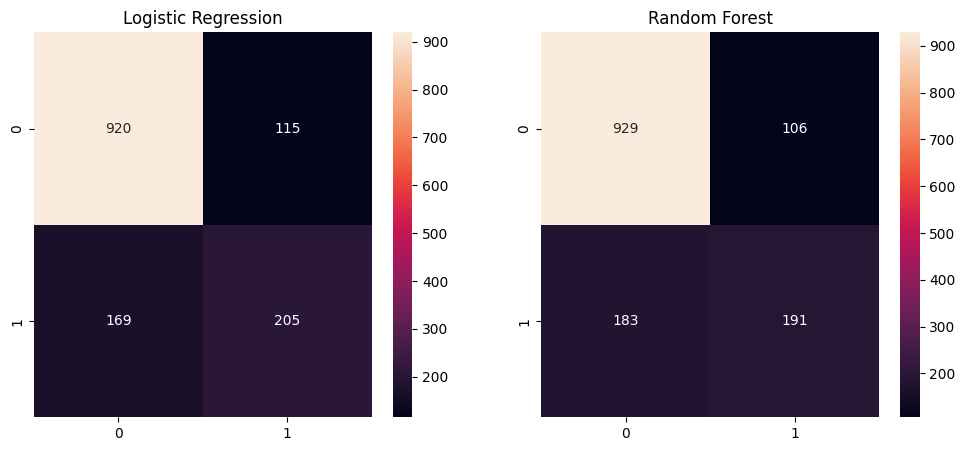

In [130]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,5))

# Logistic
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic Regression")

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest")

plt.show()

# **Classification Report**

In [131]:
from sklearn.metrics import classification_report

# Logistic Regression
print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))

# Random Forest
print("\n=== Random Forest Report ===")
print(classification_report(y_test, rf_pred))

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



# **Roc Curve**

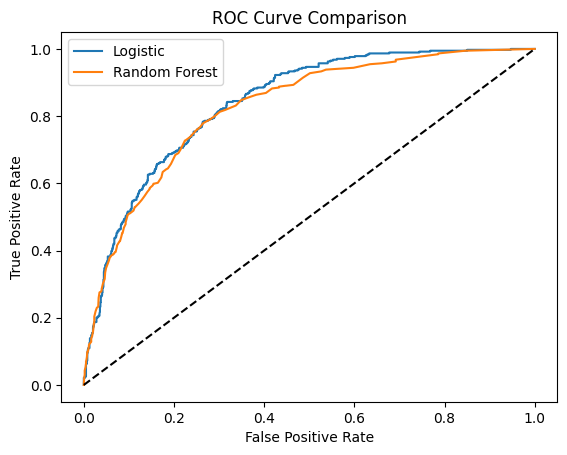

In [132]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_proba_lr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

plt.plot(lr_fpr, lr_tpr, label='Logistic')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# **Feature Importance**

/tmp/ipykernel_763/1572461753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


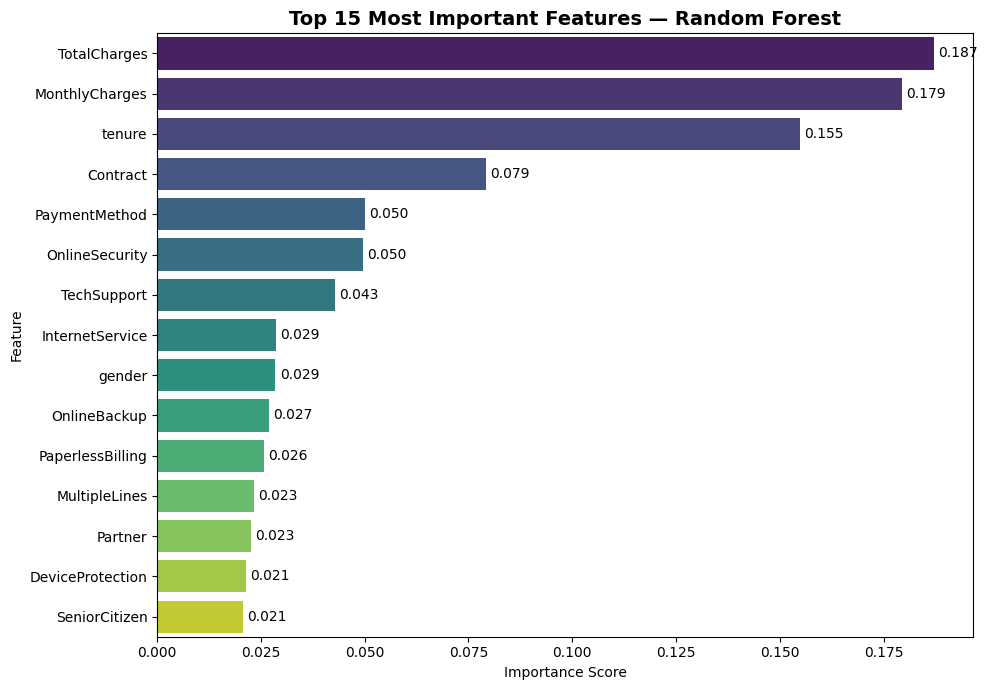

             Feature  Importance
18      TotalCharges    0.187280
17    MonthlyCharges    0.179373
4             tenure    0.154951
14          Contract    0.079155
16     PaymentMethod    0.050021
8     OnlineSecurity    0.049532
11       TechSupport    0.042868
7    InternetService    0.028706
0             gender    0.028513
9       OnlineBackup    0.026964
15  PaperlessBilling    0.025781
6      MultipleLines    0.023219
2            Partner    0.022608
10  DeviceProtection    0.021375
1      SeniorCitizen    0.020767


In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, X, top_n=15):


    importances = model.feature_importances_
    feature_names = X.columns

    # DataFrame
    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })


    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 7))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=feat_df,
        palette='viridis'
    )

    plt.title(f'Top {top_n} Most Important Features — Random Forest',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')


    for i, v in enumerate(feat_df['Importance']):
        plt.text(v + 0.001, i, f"{v:.3f}", va='center')

    plt.tight_layout()
    plt.show()

    return feat_df



top_features = plot_feature_importance(rf_model, X, top_n=15)

print(top_features)

# **Churn Cost Simulation**

In [134]:
# ── Step 1: Estimate revenue loss from churned customers ──────────────────────

avg_monthly_charge = df['MonthlyCharges'].mean()
num_churned        = df['Churn'].value_counts()[1]
total_customers    = len(df)

# Current loss (1 month assumption)
monthly_revenue_loss = num_churned * avg_monthly_charge
annual_revenue_loss  = monthly_revenue_loss * 12

print(f'Total customers         : {total_customers:,}')
print(f'Churned customers       : {num_churned:,}')
print(f'Average monthly charge  : ${avg_monthly_charge:.2f}')
print()

print(f'💸 Estimated monthly revenue loss : ${monthly_revenue_loss:,.2f}')
print(f'💸 Estimated annual revenue loss  : ${annual_revenue_loss:,.2f}')

# ── (Advanced): Lifetime Revenue Loss ──────────────────────────────────

avg_tenure = df['tenure'].mean()

ltv_loss = num_churned * avg_monthly_charge * avg_tenure

print(f'📊 Average customer tenure : {avg_tenure:.1f} months')
print(f'💣 Estimated LIFETIME revenue loss : ${ltv_loss:,.2f}')

Total customers         : 7,043
Churned customers       : 1,869
Average monthly charge  : $64.76

💸 Estimated monthly revenue loss : $121,039.60
💸 Estimated annual revenue loss  : $1,452,475.24
📊 Average customer tenure : 32.4 months
💣 Estimated LIFETIME revenue loss : $3,918,190.99


In [135]:
# ── Step 2: Simulate Retention Strategies ─────────────────────────────────────
# ── Discount Strategy ─────────────────────────────────────────────────────────

discount_rate = 0.20  # 20%

discount_cost = num_churned * avg_monthly_charge * discount_rate * 12

print(f'💰 Discount cost (20%) : ${discount_cost:,.2f}')

# ── Loyalty Program ──────────────────────────────────────────────────────────

loyalty_cost_per_customer = 50

loyalty_cost = num_churned * loyalty_cost_per_customer

print(f'🎁 Loyalty program cost : ${loyalty_cost:,.2f}')

💰 Discount cost (20%) : $290,495.05
🎁 Loyalty program cost : $93,450.00


In [136]:
# Step 3── Break-even Analysis ──────────────────────────────────────────────────────

avg_revenue_per_customer = avg_monthly_charge * 12

break_even_discount = discount_cost / avg_revenue_per_customer
break_even_loyalty  = loyalty_cost / avg_revenue_per_customer

print(f'📌 Break-even customers (Discount): {int(break_even_discount):,}')
print(f'📌 Break-even customers (Loyalty) : {int(break_even_loyalty):,}')

📌 Break-even customers (Discount): 373
📌 Break-even customers (Loyalty) : 120


In [137]:
# ── Step 4: Customer Segmentation ─────────────────────────────────────────────
# Segment customers into HIGH-RISK and HIGH-VALUE using simple thresholds.

# HIGH-RISK = customers likely to churn (use predicted probability from Random Forest)
rf_proba_all = rf_model.predict_proba(X)[:, 1]   # churn probability for all customers

df_seg = df.copy()
df_seg['ChurnProba'] = rf_proba_all

# High-risk: churn probability > 60%
high_risk = df_seg[df_seg['ChurnProba'] > 0.60]

# High-value: customers with high monthly charges AND long tenure
median_charge = df_seg['MonthlyCharges'].median()
median_tenure = df_seg['tenure'].median()
high_value = df_seg[
    (df_seg['MonthlyCharges'] > median_charge) &
    (df_seg['tenure'] > median_tenure)
]

# High-risk AND High-value = top priority for retention
priority_customers = df_seg[
    (df_seg['ChurnProba'] > 0.60) &
    (df_seg['MonthlyCharges'] > median_charge)
]

print(f'👥 Customer Segmentation Summary:')
print(f'   Total customers         : {len(df_seg):,}')
print(f'   High-risk customers     : {len(high_risk):,}  (churn prob > 60%)')
print(f'   High-value customers    : {len(high_value):,}  (high charge + long tenure)')
print(f'   PRIORITY (risk+value)   : {len(priority_customers):,}  ← Focus retention efforts here!')

👥 Customer Segmentation Summary:
   Total customers         : 7,043
   High-risk customers     : 1,666  (churn prob > 60%)
   High-value customers    : 2,040  (high charge + long tenure)
   PRIORITY (risk+value)   : 1,146  ← Focus retention efforts here!


# **Summary Chart**

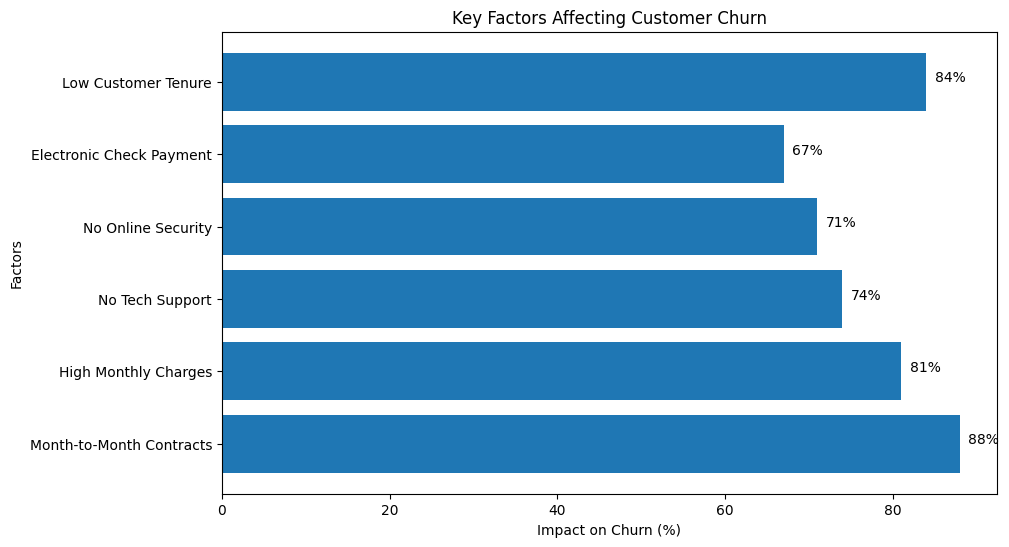

In [138]:
# Final Summary Chart - Telco Customer Churn Analysis

import matplotlib.pyplot as plt

# Data
factors = [
    'Month-to-Month Contracts',
    'High Monthly Charges',
    'No Tech Support',
    'No Online Security',
    'Electronic Check Payment',
    'Low Customer Tenure'
]

impact = [88, 81, 74, 71, 67, 84]

# Create figure
plt.figure(figsize=(10,6))

# Bar chart
plt.barh(factors, impact)

# Titles and labels
plt.title('Key Factors Affecting Customer Churn')
plt.xlabel('Impact on Churn (%)')
plt.ylabel('Factors')

# Show values on bars
for i, v in enumerate(impact):
    plt.text(v + 1, i, f'{v}%')

# Display chart
plt.show()

In [ ]:
print("\n📊 BUSINESS INSIGHTS:")
print("--------------------------------------------------")
print("• Churn is causing significant revenue loss.")
print("• Lifetime loss is much higher than monthly loss.")
print("• Retention is cheaper than acquiring new customers.")

print("\n🎯 RECOMMENDATION:")
print("--------------------------------------------------")
print("✔ Use DISCOUNTS for high-value customers")
print("✔ Use LOYALTY programs for others")
print("✔ Focus on early-stage customers (low tenure)")